# Grids and States

In this second tutorial, we will explore the fundamental building blocks of any SAETASS simulation: the **Grid** and the **State**. Both are built from the Astropy Quantities introduced in the previous tutorial.

## 1. What is a Grid?

In SAETASS, a `Grid` object defines the discrete coordinates where our physical values live. Since SAETASS is designed for astrophysical transport (like cosmic rays), it handles two main types of coordinates:
- **Spatial (r)**: Usually representing radial distance in a spherical system.
- **Momentum (p)**: Representing the particle momentum.

Let's start by importing the necessary modules.

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from saetass import units as su
from saetass.grid import Grid
from saetass.state import State
from saetass.utils.energy_losses import Particle

### Creating a basic Grid

The easiest way to create a grid is using the `Grid.uniform` factory method. This creates a linearly spaced grid in the specified ranges, which are given as Quantities in any length unit.

In [2]:
# Create a uniform spatial grid from 0 to 10 pc with 100 cells
grid = Grid.uniform(r_min=0.0 * u.pc, r_max=10.0 * u.pc, num_r_cells=100)

print(grid)

Grid:
  Spatial range: -5.0505e-02 to 1.0051e+01 pc
  Number of spatial cells: 100


### Scientific Grids: Logarithmic Spacing

In astrophysics, momentum/energy spectra often span many orders of magnitude. For these cases, a `log_spaced` grid is much more appropriate.

In [3]:
# Create a log-spaced momentum grid from 1 GeV/c to 100 TeV/c
p_grid = Grid.log_spaced(
    p_min=1.0 * su.MOMENTUM, p_max=1e5 * su.MOMENTUM, num_p_cells=40
)

print(p_grid)

Grid:
  Momentum range: 8.2830e-01 to 1.1278e+05 GeV_c
  Number of momentum cells: 40


## 2. What is a State?

A `State` is the object that actually carries the physics. It contains the differential density $\psi_p(r, p) = \frac{dn}{dp}$ and keeps track of the simulation time and metadata.

The distribution can be given in any of its representations, the phase-space distribution `f_ps`, the momentum differential density `psi_p` or the energy differential density `psi_E`, as long as it has the corresponding units. Let's create a `State` for our spatial grid with an initial Gaussian distribution.

In [4]:
# Define an initial profile: a Gaussian centered at r = 5 pc
r = grid.r_centers
psi_initial = np.exp(-((r - 5.0 * u.pc) ** 2) / (2 * (0.5 * u.pc) ** 2))
psi_initial = psi_initial * u.cm**-3 / su.MOMENTUM

# Instantiate the State object
state = State(grid, psi_p=psi_initial, particle=Particle.PROTON)

print(state)

State(t=0.000 Myr, dt=0.000 Myr, stage=0, stage_name='', particle='proton' (hadronic), shape=(1, 100), history_len=0)


## 3. Visualizing the Initial Condition

One of the best ways to understand your setup is to plot it. `state.psi_p` returns the distribution as a Quantity in canonical units, which we convert to the units we want to plot with `to_value()`.

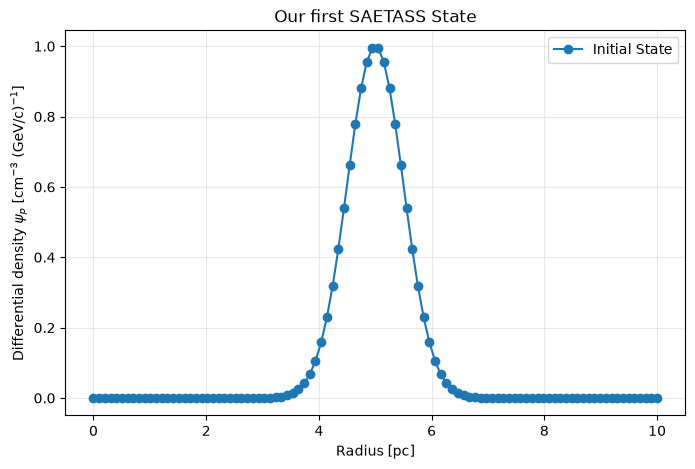

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(
    grid.r_centers.to_value(u.pc),
    state.psi_p.to_value(u.cm**-3 / su.MOMENTUM),
    "o-",
    label="Initial State",
)
plt.xlabel("Radius [pc]")
plt.ylabel(r"Differential density $\psi_p$ [cm$^{-3}$ (GeV/c)$^{-1}$]")
plt.title("Our first SAETASS State")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Summary

In this tutorial, you learned:
1. How to create **uniform** and **log-spaced** grids from Quantities.
2. How to initialize a **State** with a physical distribution.
3. How to access the data, in any units, for **visualization**.

In the next tutorial, we will see how to put this state inside a **Solver** to see how it evolves over time!